# Gemelo final del beamline: transmisión y distancia acoplados

Este notebook une dos emuladores en **un solo gemelo** con dos cabezas sobre el
mismo espacio de entrada (el cubo unitario de los 8 voltajes):

- **Cabeza de transmisión**: GP sobre `log1p(hits)`. Modela
  la cantidad objetivo, pero sola es ciega en el ~90% del espacio donde `hits = 0` (todos los
  ceros le parecen iguales).
- **Cabeza de distancia**: GP sobre `log1p` de la
  distancia media al centro del detector. Continua en todas partes: ordena justo la meseta
  donde la otra cabeza no tiene señal.

**El acople:** la cabeza de distancia se convierte en `p_close` -- la probabilidad de que el
haz caiga cerca del detector -- y todo lo que decide la cabeza de transmisión (adquisición y
tareas de control) queda multiplicado/filtrado por esa probabilidad. El umbral del gate es
**adaptativo**: el cuartil mejor de las distancias observadas, con `CLOSE_MM` como piso. Así,
mientras nada haya caído dentro de `CLOSE_MM`, el gate pregunta "¿tan cerca como el mejor
cuarto de lo visto?" en vez de colapsar a cero en todas partes, y se aprieta solo a medida que
llegan datos buenos.

**Un solo conjunto de datos:** el gemelo genera sus propios datos de SIMION (diseño inicial con
**el estudio de Optuna que ya está implementado en `optimizer.py`** y todo vive en `beamline_distance_results.csv`, donde cada corrida guarda hits
**y** distancia. Las dos cabezas se entrenan siempre con las mismas filas, así que el gate está
activo desde el primer ajuste.

Restricción de diseño: `gp.py` y `acquisition.py` no se tocan. Lo nuevo vive en `gp_final.py`
(`BeamlineEmulator`, construido sobre `gp.py` y `gp_distance.py`) y `acquisition_final.py`
(EI acoplado + las dos tareas de control), reutilizando los generadores de candidatos de
`acquisition_distance.py`.

In [1]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")  # must run before numpy is imported
os.environ.setdefault("OMP_NUM_THREADS", "1")
# Same OpenBLAS pin as notebooks 05/06.

import sys, pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
SIM_FOLDER = HERE / "simion_opt_v"
for p in (str(HERE), str(SIM_FOLDER)):
    if p not in sys.path:
        sys.path.insert(0, p)

from gp_final import BeamlineEmulator
from acquisition_final import (coupled_expected_improvement, propose_next_point,
                               best_predicted_point, match_predicted_point)
from acquisition_distance import sobol_candidates
import optimizer  # apply_voltages, run_simion, FLY_COMMAND, get_positions, count_hits, DETECTOR_REGION

SEED = 0
rng = np.random.default_rng(SEED)

c:\Users\Administrador\anaconda3\envs\env_name\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Electrodos, rangos y referencias físicas

Mismos 8 electrodos y `BOUNDS` del `optimizer.py` (bender V9-V12 acotado al semiespacio de
signo informativo). La física entra solo aquí y en el objetivo: el GP y las adquisiciones
siguen siendo genéricos.

In [2]:
ELECTRODES = [3, 6, 9, 10, 11, 12, 15, 18]
BOUNDS = np.array([
    (-1000.0, 1000.0),  # V3  Einzel lens 1
    (-1000.0, 1000.0),  # V6  Einzel lens 2
    (0.0, 1000.0),      # V9  quadrupole bender -- informativo solo si V9 > 0
    (0.0, 1000.0),      # V10 quadrupole bender -- informativo solo si V10 > 0
    (0.0, 1000.0),      # V11 quadrupole bender -- informativo solo si V11 > 0
    (-1000.0, 0.0),     # V12 quadrupole bender -- informativo solo si V12 < 0
    (-1000.0, 1000.0),  # V15 deflection plate 1
    (-1000.0, 1000.0),  # V18 deflection plate 2
])
N_IONS = 500           # ions fired per fly (SimpleSetUp.fly2)
MAX_DISTANCE_MM = 500.0  # penalización sin iones registrados y cota superior admisible
CLOSE_MM = 20.0        # "cerca" = a menos de ~20 mm del centro (el detector mide ~12 x 13 x 4 mm)

def to_unit(X, bounds=BOUNDS):
    """Map real voltages to the unit cube, one range per electrode."""
    return (X - bounds[:, 0]) / (bounds[:, 1] - bounds[:, 0])

def to_real(U, bounds=BOUNDS):
    """Map the unit cube back to real voltages."""
    return bounds[:, 0] + U * (bounds[:, 1] - bounds[:, 0])

DETECTOR_CENTER = np.array([np.mean(optimizer.DETECTOR_REGION[k]) for k in ("x", "y", "z")])
print("centro del detector (mm):", DETECTOR_CENTER)

centro del detector (mm): [ 76.   76.5 405. ]


In [ ]:
# produce hits Y distancia, y se anexa de inmediato al CSV incremental.
DISTANCE_CSV = SIM_FOLDER / "beamline_distance_results.csv"
VOLT_COLS = [f"V{e}" for e in ELECTRODES]

def mean_distance_to_detector(positions):
    """Distancia euclidiana media (mm) de los impactos registrados al centro del detector."""
    if positions.shape[0] == 0:
        return MAX_DISTANCE_MM
    d = np.linalg.norm(positions - DETECTOR_CENTER[None, :], axis=1)
    return float(np.clip(d.mean(), 0.0, MAX_DISTANCE_MM))

def simion_fly(x_unit):
    """One real SIMION fly at x_unit (unit cube). Returns (distance_mm, hits, n_recorded)."""
    voltages = to_real(np.asarray(x_unit).reshape(1, -1))[0]
    optimizer.apply_voltages(dict(zip(ELECTRODES, voltages)))
    output = optimizer.run_simion(optimizer.FLY_COMMAND)
    positions = optimizer.get_positions(output)
    hits = optimizer.count_hits(positions) if positions.shape[0] else 0
    return mean_distance_to_detector(positions), hits, int(positions.shape[0])

def append_result(x_unit, distance_mm, hits, n_recorded, phase):
    """Append one evaluated point to the incremental CSV (never lose a paid SIMION run)."""
    voltages = to_real(np.asarray(x_unit).reshape(1, -1))[0]
    row = dict(zip(VOLT_COLS, voltages))
    row.update(distance_mm=distance_mm, hits=hits, n_recorded=n_recorded, phase=phase)
    pd.DataFrame([row]).to_csv(DISTANCE_CSV, mode="a",
                               header=not DISTANCE_CSV.exists(), index=False)

def load_distance_results():
    if DISTANCE_CSV.exists():
        return pd.read_csv(DISTANCE_CSV)
    return pd.DataFrame(columns=VOLT_COLS + ["distance_mm", "hits", "n_recorded", "phase"])

## Conjunto de datos

Este gemelo trabaja únicamente con `beamline_distance_results.csv`: cada corrida de SIMION
guarda voltajes, `hits` **y** `distance_mm`, así que las dos cabezas se entrenan con las
mismas filas y quedan siempre consistentes entre sí.

Si el CSV está vacío, la celda siguiente lo genera corriendo **el mismo
estudio de Optuna que `optimizer.py` ya implementa** (mismo `direction`, `storage`,
`study_name` y `STARTING_POINT` de warm start). Cada trial se anota con la misma
corrida de SIMION que produce `hits` **y** `distance_mm` (vía `simion_fly`), así que ninguna
evaluación se desperdicia para la cabeza de distancia aunque Optuna la haya elegido para
explotar y no para explorar. Como siempre, detrás de un flag que empieza en `False` porque cada
punto es una corrida real; cada evaluación se acumula de inmediato.

In [4]:
RUN_INITIAL_DESIGN = False   # flip to True deliberately -- each point is one real SIMION run
N_INITIAL = optimizer.N_TRIALS   # mismo presupuesto que optimizer.py; bájalo si el presupuesto aprieta

if RUN_INITIAL_DESIGN:
    import optuna
    import subprocess

    optimizer.check_setup()

    def optuna_objective(trial):
        """Same per-trial logic as optimizer.objective (TASK 2a): Optuna
        suggests a voltage per free electrode from the SAME ranges
        (`optimizer.OPTIMIZE`). The only difference is that the score comes
        from `simion_fly` instead of `optimizer.count_hits` directly, so the
        one real SIMION flight per trial also yields `distance_mm` for the
        twin's second head, and every trial is persisted immediately -- a
        paid trial is never lost even if it scores 0.
        """
        chosen = {number: trial.suggest_float(f"V{number}", low, high)
                  for number, (low, high) in optimizer.OPTIMIZE.items()}
        voltages = np.array([[chosen[e] for e in ELECTRODES]])
        x = to_unit(voltages)[0]
        try:
            distance_mm, hits, n_rec = simion_fly(x)
        except subprocess.CalledProcessError:
            return optimizer.BAD_SCORE
        append_result(x, distance_mm, hits, n_rec, phase="initial")
        print(f"trial {trial.number:3d}: dist={distance_mm:8.2f} mm  hits={hits:3d}  "
              f"registrados={n_rec:3d}  V={np.round(voltages[0], 1)}")
        return hits

    # El MISMO estudio que optimizer.py propone (misma dirección, mismo storage,
    # mismo study_name, mismo warm start).
    study = optuna.create_study(
        direction=optimizer.DIRECTION,
        storage=f"sqlite:///{optimizer.RESULTS_DB}",
        study_name=optimizer.STUDY_NAME,
        load_if_exists=True,
    )
    if optimizer.STARTING_POINT:
        study.enqueue_trial(optimizer.STARTING_POINT)   # mismo warm start que optimizer.py
    study.optimize(optuna_objective, n_trials=N_INITIAL, n_jobs=1, show_progress_bar=True)

    print(f"\ngasto de esta celda: {N_INITIAL} evaluaciones nuevas "
          f"(anotar contra el presupuesto ")
    print(f"mejor trial de este estudio: hits={study.best_value:.0f}  V={study.best_params}")
else:
    print("RUN_INITIAL_DESIGN=False: no se gastó presupuesto de SIMION en esta celda.")

RUN_INITIAL_DESIGN=False: no se gastó presupuesto de SIMION en esta celda.


In [5]:
df_data = load_distance_results()
HAVE_DATA = len(df_data) >= 8
print(f"{len(df_data)} evaluaciones acumuladas en {DISTANCE_CSV.name}")

if HAVE_DATA:
    # Un solo conjunto de datos: las mismas filas alimentan las dos cabezas.
    U_data = to_unit(df_data[VOLT_COLS].to_numpy(dtype=float))
    hits_data = df_data["hits"].to_numpy(dtype=float)
    d_data = df_data["distance_mm"].to_numpy(dtype=float)
    print(f"informativos (hits > 0): {int((hits_data > 0).sum())}/{len(hits_data)}   "
          f"mejor distancia: {d_data.min():.1f} mm   mejor transmisión: {hits_data.max():.0f}")
else:
    print("Aún no hay datos suficientes: corre la celda anterior con RUN_INITIAL_DESIGN=True.")

150 evaluaciones acumuladas en beamline_distance_results.csv
informativos (hits > 0): 77/150   mejor distancia: 3.5 mm   mejor transmisión: 24


## Cobertura del espacio de datos

Con las evaluaciones acumuladas en `beamline_distance_results.csv`, revisamos qué tan bien
queda cubierto el espacio de voltajes para las dos cantidades que entrena el gemelo:
**transmisión** (`hits`, discreta y escasa: la mayoría de las evaluaciones caen en cero) y
**distancia media al detector** (`distance_mm`, continua en todo el espacio). Es justo esa
continuidad la que le da a la cabeza de distancia señal donde la transmisión no tiene
ninguna.

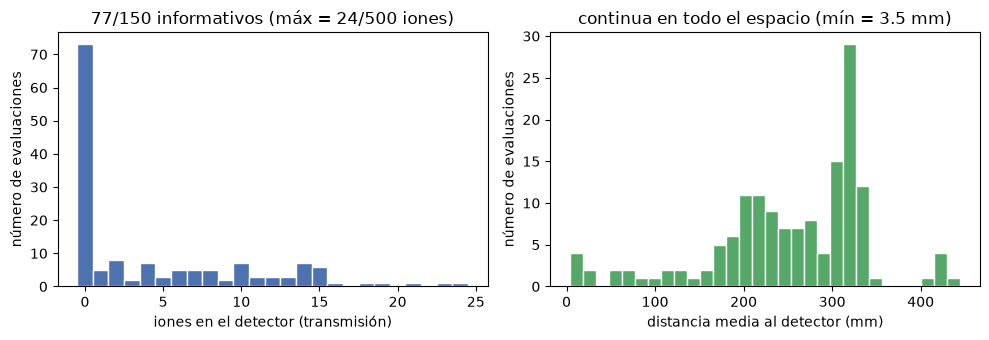

fracción de evaluaciones informativas (hits > 0): 51.3%
mejor distancia observada: 3.5 mm   mejor transmisión observada: 24


In [6]:
if HAVE_DATA:
    n_hit = int((hits_data > 0).sum())
    n_total = len(hits_data)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

    bins_hits = np.arange(0, hits_data.max() + 2) - 0.5
    axes[0].hist(hits_data, bins=bins_hits, color="#4c72b0", edgecolor="white")
    axes[0].set_xlabel("iones en el detector (transmisión)")
    axes[0].set_ylabel("número de evaluaciones")
    axes[0].set_title(f"{n_hit}/{n_total} informativos (máx = {hits_data.max():.0f}/{N_IONS} iones)")

    axes[1].hist(d_data, bins=30, color="#55a868", edgecolor="white")
    axes[1].set_xlabel("distancia media al detector (mm)")
    axes[1].set_ylabel("número de evaluaciones")
    axes[1].set_title(f"continua en todo el espacio (mín = {d_data.min():.1f} mm)")

    plt.tight_layout()
    plt.show()

    print(f"fracción de evaluaciones informativas (hits > 0): {n_hit/n_total:.1%}")
    print(f"mejor distancia observada: {d_data.min():.1f} mm   mejor transmisión observada: {hits_data.max():.0f}")
else:
    print("Sin datos todavía: corre RUN_INITIAL_DESIGN=True primero.")

## Entrenar el gemelo

Un solo objeto `BeamlineEmulator` (en `gp_final.py`): las dos cabezas se ajustan con
hiperparámetros ARD propios (maximizando la log-marginal-likelihood cada una), pero comparten
espacio de entrada, cotas admisibles y el gate de proximidad.

In [7]:
if HAVE_DATA:
    twin = BeamlineEmulator(n_ions=N_IONS, max_distance_mm=MAX_DISTANCE_MM, close_mm=CLOSE_MM)
    twin.fit_transmission(U_data, hits_data, n_restarts=8, seed=SEED)
    twin.fit_distance(U_data, d_data, n_restarts=8, seed=SEED)

    print("lengthscales cabeza de transmisión (cubo unitario):")
    for e, l in zip(ELECTRODES, twin.gp_hits.lengthscale):
        print(f"  V{e}: {l:.3f}")
    print(f"signal_var: {twin.gp_hits.signal_var:.3f}   noise_var: {twin.gp_hits.noise_var:.4f}")

    print("\nlengthscales cabeza de distancia (cubo unitario):")
    for e, l in zip(ELECTRODES, twin.gp_dist.lengthscale):
        print(f"  V{e}: {l:.3f}")
    print(f"signal_var: {twin.gp_dist.signal_var:.3f}   noise_var: {twin.gp_dist.noise_var:.4f}")
else:
    print("Sin datos suficientes: el gemelo no se puede entrenar todavía.")

lengthscales cabeza de transmisión (cubo unitario):
  V3: 0.209
  V6: 0.668
  V9: 5.602
  V10: 0.187
  V11: 0.510
  V12: 0.344
  V15: 1.495
  V18: 83.262
signal_var: 0.978   noise_var: 0.2997

lengthscales cabeza de distancia (cubo unitario):
  V3: 0.098
  V6: 148.413
  V9: 148.413
  V10: 0.096
  V11: 0.094
  V12: 0.163
  V15: 0.128
  V18: 0.627
signal_var: 0.567   noise_var: 0.0100


## Validación de la cabeza de transmisión

Split estratificado para que ambos lados tengan trials con
`hits > 0`. Se reporta el MAE en la región informativa y el
global, en iones reales.

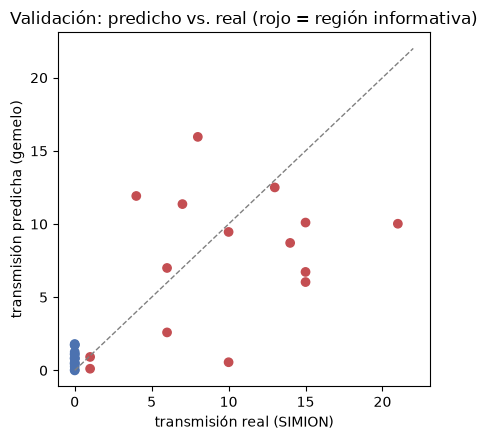

MAE en la región informativa (criterio A): 4.966 iones sobre 15 puntos
MAE global: 2.916 iones sobre 30 puntos


In [8]:
def stratified_split(y, frac_val=0.2, seed=SEED):
    rng_s = np.random.default_rng(seed)
    hit_idx = np.flatnonzero(y > 0)
    zero_idx = np.flatnonzero(y == 0)
    rng_s.shuffle(hit_idx)
    rng_s.shuffle(zero_idx)
    n_val_hit = max(1, int(round(len(hit_idx) * frac_val))) if len(hit_idx) else 0
    n_val_zero = int(round(len(zero_idx) * frac_val))
    val_idx = np.concatenate([hit_idx[:n_val_hit], zero_idx[:n_val_zero]])
    train_idx = np.setdiff1d(np.arange(len(y)), val_idx)
    return train_idx, val_idx

if HAVE_DATA and len(df_data) >= 20 and (hits_data > 0).any():
    train_idx, val_idx = stratified_split(hits_data, frac_val=0.2, seed=SEED)
    twin_val = BeamlineEmulator(n_ions=N_IONS, max_distance_mm=MAX_DISTANCE_MM, close_mm=CLOSE_MM)
    twin_val.fit_transmission(U_data[train_idx], hits_data[train_idx], n_restarts=8, seed=SEED)
    pred_val, _, _ = twin_val.predict_transmission(U_data[val_idx])
    real_val = hits_data[val_idx]

    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    lim = max(real_val.max(), pred_val.max()) + 1
    ax.plot([0, lim], [0, lim], color="gray", ls="--", lw=1)
    ax.scatter(real_val, pred_val, c=np.where(real_val > 0, "#c44e52", "#4c72b0"))
    ax.set_xlabel("transmisión real (SIMION)")
    ax.set_ylabel("transmisión predicha (gemelo)")
    ax.set_title("Validación: predicho vs. real (rojo = región informativa)")
    plt.tight_layout()
    plt.show()

    informative = real_val > 0
    if informative.any():
        mae_inf = np.abs(real_val[informative] - pred_val[informative]).mean()
        print(f"MAE en la región informativa (criterio A): {mae_inf:.3f} iones "
              f"sobre {int(informative.sum())} puntos")
    print(f"MAE global: {np.abs(real_val - pred_val).mean():.3f} iones sobre {len(real_val)} puntos")
else:
    print("Se necesitan >= 20 evaluaciones (con alguna informativa) para validar con sentido.")

## El gate en acción (sin gastar SIMION)

Un barrido Sobol de candidatos muestra cómo se acoplan las cabezas: la transmisión predicha
(eje x) contra `p_close` (eje y). Solo el cuadrante superior derecho
sobrevive al producto -- puntos donde la cabeza de hits *cree* que hay señal pero la de
distancia dice que el haz ni se acerca (abajo a la derecha) quedan anulados. Ese cuadrante es
exactamente el modo de falla de la tarea de dirección basada en trasmisión solamente.

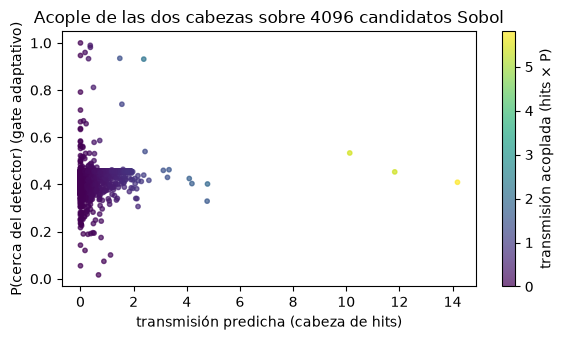

In [9]:
if HAVE_DATA:
    demo = sobol_candidates(4096, len(ELECTRODES), seed=SEED)
    hits_mean, _, _ = twin.predict_transmission(demo)
    p_demo = twin.p_close(demo)

    fig, ax = plt.subplots(figsize=(6, 3.5))
    sc = ax.scatter(hits_mean, p_demo, c=hits_mean * p_demo, cmap="viridis", s=10, alpha=0.7)
    fig.colorbar(sc, label="transmisión acoplada (hits × P)")
    ax.set_xlabel("transmisión predicha (cabeza de hits)")
    ax.set_ylabel("P(cerca del detector) (gate adaptativo)")
    ax.set_title("Acople de las dos cabezas sobre 4096 candidatos Sobol")
    plt.tight_layout()
    plt.show()
else:
    print("Demo del acople omitida: el gemelo no está entrenado aún.")

## Aprendizaje activo con EI acoplado

`propose_next_point` (en `acquisition_final.py`) puntúa candidatos con
`EI(transmisión) × P(cerca)`: mejora esperada en hits, pero solo donde la cabeza de distancia
cree que el haz llega al detector. Cada corrida real alimenta **las dos cabezas** (hits y
distancia salen del mismo fly) y se acumula antes de refitear. Hiperparámetros se
re-optimizan cada `REFIT_HYPERS_EVERY` iteraciones.

Como siempre: el flag empieza en `False` porque cada iteración gasta presupuesto real de
SIMION.

In [10]:
RUN_ACTIVE_LEARNING = True   # flip to True deliberately -- consumes real SIMION budget
SIMION_BUDGET = 20            # reemplazar con lo que quede del presupuesto de entrenamiento
REFIT_HYPERS_EVERY = 5

if RUN_ACTIVE_LEARNING and HAVE_DATA:
    optimizer.check_setup()
    U_active = U_data.copy()
    hits_active = hits_data.copy()
    d_active = d_data.copy()

    for i in range(SIMION_BUDGET):
        x_next, score = propose_next_point(twin, U_active, np.log1p(hits_active),
                                           seed=SEED + i)
        distance_mm, hits_next, n_rec = simion_fly(x_next)
        append_result(x_next, distance_mm, hits_next, n_rec, phase="coupled")
        print(f"iter {i:2d}: hits={hits_next:3d}  dist={distance_mm:8.2f} mm  EIxP={score:.4f}  "
              f"V={np.round(to_real(x_next.reshape(1, -1))[0], 1)}")

        # la misma corrida alimenta las dos cabezas
        U_active = np.vstack([U_active, x_next])
        hits_active = np.append(hits_active, hits_next)
        d_active = np.append(d_active, distance_mm)

        if (i + 1) % REFIT_HYPERS_EVERY == 0:
            twin.fit_transmission(U_active, hits_active, n_restarts=8, seed=SEED)
            twin.fit_distance(U_active, d_active, n_restarts=8, seed=SEED)
        else:
            twin.refit_transmission(U_active, hits_active)
            twin.refit_distance(U_active, d_active)

    print(f"\ngasto de este loop: {SIMION_BUDGET} evaluaciones nuevas "
          f"(anotar junto al total ya usado -- InfoHackathon.md seccion 7.6)")
elif RUN_ACTIVE_LEARNING:
    print("No hay datos iniciales: corre primero el diseño inicial.")
else:
    print("RUN_ACTIVE_LEARNING=False: no se gastó presupuesto de SIMION en esta celda.")

Found SIMION and the simulation files. Good to go!
  ions on detector: 4
iter  0: hits=  4  dist=  240.34 mm  EIxP=0.0235  V=[-302.1 -968.1  158.8  137.7   16.3 -702.9 -497.6 -532.4]
  ions on detector: 11
iter  1: hits= 11  dist=  166.12 mm  EIxP=0.0071  V=[-481.  -989.   163.8   84.3   59.6 -793.3 -638.3 -380.6]
  ions on detector: 0
iter  2: hits=  0  dist=  420.69 mm  EIxP=0.0022  V=[ 989.2  825.4  678.8  928.1  901.3  -55.4 -395.7  720.3]
  ions on detector: 29
iter  3: hits= 29  dist=  163.86 mm  EIxP=0.0030  V=[-445.5 -994.5  221.8   98.1   68.  -719.1 -510.3 -316.9]
  ions on detector: 15
iter  4: hits= 15  dist=  190.55 mm  EIxP=0.0020  V=[ -432.6 -1000.    274.9    80.2     7.1  -736.3  -527.8  -330. ]
  ions on detector: 0
iter  5: hits=  0  dist=  421.79 mm  EIxP=0.0015  V=[ 972.  -539.6  129.7  991.5  974.2  -42.1  658.   151.6]
  ions on detector: 26
iter  6: hits= 26  dist=  172.61 mm  EIxP=0.0017  V=[-419.  -840.   210.9   87.4   36.6 -699.2 -502.6 -402.2]
  ions on det

## Las dos tareas de control

Ambas se resuelven sobre el gemelo acoplado y se verifican con **una sola corrida real** cada
una (no cuenta contra el presupuesto de entrenamiento):

- **Dirección**: maximizar la transmisión acoplada y conservadora
  `expm1(media − β·std) × P(cerca)`. El descuento por incertidumbre evita los puntos donde la
  cabeza de hits *alucina* media alta por pura extrapolación, y el gate veta las regiones donde
  el haz ni se acerca. El refinamiento por gradiente solo acepta pasos que mejoran ese mismo
  score, así no puede escaparse de la región confiable (el modo de falla del modelo con trasmisión solamente).
- **Consigna inversa**: dado un objetivo de transmisión, el candidato cuya predicción quede
  más cerca, descontando incertidumbre (`beta × std`) y compitiendo solo donde
  `P(cerca) >= p_min`.

In [11]:
RUN_CONTROL_TASKS = True   # flip to True deliberately -- spends one verification run per task

if RUN_CONTROL_TASKS and HAVE_DATA:
    optimizer.check_setup()
    x_dir = best_predicted_point(twin, seed=SEED)
    x_arr = x_dir.reshape(1, -1)
    pred_hits_dir, _, _ = twin.predict_transmission(x_arr)
    p_dir = twin.p_close(x_arr)[0]
    pred_dist_dir = twin.predict_distance(x_arr)

    dist_real, hits_real, n_rec = simion_fly(x_dir)
    append_result(x_dir, dist_real, hits_real, n_rec, phase="verification")

    print("=== Tarea de dirección (máxima transmisión, con gate de proximidad) ===")
    print("voltajes recomendados:", dict(zip(ELECTRODES, np.round(to_real(x_arr)[0], 1))))
    extra = f"   distancia predicha: {pred_dist_dir[0][0]:.1f} mm" if pred_dist_dir is not None else ""
    print(f"transmisión predicha: {pred_hits_dir[0]:.2f}   P(cerca): {p_dir:.2f}{extra}")
    print(f"transmisión real:     {hits_real}   distancia real: {dist_real:.2f} mm")
else:
    print("RUN_CONTROL_TASKS=False (o sin datos): no se corrió la tarea de dirección.")

Found SIMION and the simulation files. Good to go!
  ions on detector: 23
=== Tarea de dirección (máxima transmisión, con gate de proximidad) ===
voltajes recomendados: {3: np.float64(-422.4), 6: np.float64(-1000.0), 9: np.float64(272.8), 10: np.float64(51.0), 11: np.float64(0.0), 12: np.float64(-734.5), 15: np.float64(-1000.0), 18: np.float64(-430.3)}
transmisión predicha: 24.16   P(cerca): 0.98   distancia predicha: 170.2 mm
transmisión real:     23   distancia real: 183.41 mm


In [12]:
TARGET_TRANSMISSION = 15.0  # reemplazar con el valor que dé el instructor para esta tarea

if RUN_CONTROL_TASKS and HAVE_DATA:
    x_set = match_predicted_point(twin, TARGET_TRANSMISSION, seed=SEED)
    x_arr = x_set.reshape(1, -1)
    pred_hits_set, _, _ = twin.predict_transmission(x_arr)
    pred_dist_set = twin.predict_distance(x_arr)
    p_set = twin.p_close(x_arr)[0]

    dist_real, hits_real, n_rec = simion_fly(x_set)
    append_result(x_set, dist_real, hits_real, n_rec, phase="verification")

    print("=== Tarea de consigna inversa (con gate de proximidad) ===")
    print(f"objetivo: {TARGET_TRANSMISSION}")
    print("voltajes propuestos:", dict(zip(ELECTRODES, np.round(to_real(x_arr)[0], 1))))
    print(f"transmisión predicha: {pred_hits_set[0]:.2f}   P(cerca): {p_set:.2f}")
    print(f"distancia predicha: {pred_dist_set[0][0]:.1f}")
    print(f"transmisión real:     {hits_real}   distancia real: {dist_real:.2f} mm")
else:
    print("RUN_CONTROL_TASKS=False (o sin datos): no se corrió la tarea de consigna inversa.")

  ions on detector: 4
=== Tarea de consigna inversa (con gate de proximidad) ===
objetivo: 15.0
voltajes propuestos: {3: np.float64(-483.3), 6: np.float64(-553.7), 9: np.float64(944.1), 10: np.float64(71.6), 11: np.float64(109.3), 12: np.float64(-530.8), 15: np.float64(-486.6), 18: np.float64(-694.5)}
transmisión predicha: 5.44   P(cerca): 0.89
distancia predicha: 117.1
transmisión real:     4   distancia real: 123.59 mm


## Qué quedó y qué sigue

**Quedó:** un solo gemelo (`BeamlineEmulator`) sobre un solo conjunto de datos
(`beamline_distance_results.csv`): cada corrida de SIMION
alimenta las dos cabezas, queda guardada al instante, y el acople (`p_close`, con umbral
adaptativo) filtra la adquisición y las dos tareas de control.

**Sigue:**
- El umbral del gate ya es adaptativo (cuartil mejor de las distancias observadas, piso
  `CLOSE_MM`), pero tanto el cuantil (0.25) como el piso son perillas del acople: vale la pena
  revisarlas contra la geometría real del detector cuando la cabeza de distancia gane
  resolución.
- Acople probabilístico completo: en vez de `EI × P`, un EI restringido tipo *constrained BO*
  (EIC) o multiobjetivo (EHVI) sobre (transmisión, distancia)?